#Student Performance Analysis

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("students.csv")

df

,Student_ID,Name,Department,Python,NumPy,Pandas,Attendance
0,101,Ananya,CSE,85,78,90,92
1,102,Bhavana,CSE,72,80,75,88
2,103,Charan,ECE,65,70,68,82
3,104,Divya,CSE,92,89,95,96
4,105,Eswar,IT,55,62,58,75
5,106,Fathima,ECE,78,74,80,90
6,107,Gowtham,CSE,88,85,82,94
7,108,Harini,CSE,60,65,70,80
8,109,Ishaan,ECE,45,55,50,68
9,110,Jahnavi,IT,95,91,93,98


In [2]:
subjects = ["Python", "NumPy", "Pandas"]

df["Total"] = df[subjects].sum(axis=1)

df

,Student_ID,Name,Department,Python,NumPy,Pandas,Attendance,Total
0,101,Ananya,CSE,85,78,90,92,253
1,102,Bhavana,CSE,72,80,75,88,227
2,103,Charan,ECE,65,70,68,82,203
3,104,Divya,CSE,92,89,95,96,276
4,105,Eswar,IT,55,62,58,75,175
5,106,Fathima,ECE,78,74,80,90,232
6,107,Gowtham,CSE,88,85,82,94,255
7,108,Harini,CSE,60,65,70,80,195
8,109,Ishaan,ECE,45,55,50,68,150
9,110,Jahnavi,IT,95,91,93,98,279


In [3]:
df["Average"] = np.round(df["Total"] / 3, 2)

df

,Student_ID,Name,Department,Python,NumPy,Pandas,Attendance,Total,Average
0,101,Ananya,CSE,85,78,90,92,253,84.33
1,102,Bhavana,CSE,72,80,75,88,227,75.67
2,103,Charan,ECE,65,70,68,82,203,67.67
3,104,Divya,CSE,92,89,95,96,276,92.00
4,105,Eswar,IT,55,62,58,75,175,58.33
5,106,Fathima,ECE,78,74,80,90,232,77.33
6,107,Gowtham,CSE,88,85,82,94,255,85.00
7,108,Harini,CSE,60,65,70,80,195,65.00
8,109,Ishaan,ECE,45,55,50,68,150,50.00
9,110,Jahnavi,IT,95,91,93,98,279,93.00


In [4]:
df[["Student_ID", "Name", "Department",
    "Python", "NumPy", "Pandas",
    "Total", "Average", "Attendance"]]

,Student_ID,Name,Department,Python,NumPy,Pandas,Total,Average,Attendance
0,101,Ananya,CSE,85,78,90,253,84.33,92
1,102,Bhavana,CSE,72,80,75,227,75.67,88
2,103,Charan,ECE,65,70,68,203,67.67,82
3,104,Divya,CSE,92,89,95,276,92.00,96
4,105,Eswar,IT,55,62,58,175,58.33,75
5,106,Fathima,ECE,78,74,80,232,77.33,90
6,107,Gowtham,CSE,88,85,82,255,85.00,94
7,108,Harini,CSE,60,65,70,195,65.00,80
8,109,Ishaan,ECE,45,55,50,150,50.00,68
9,110,Jahnavi,IT,95,91,93,279,93.00,98


In [5]:
def calculate_grade(average):
    if average >= 90:
        return "A+"
    elif average >= 80:
        return "A"
    elif average >= 70:
        return "B"
    elif average >= 60:
        return "C"
    elif average >= 50:
        return "D"
    else:
        return "F"

In [6]:
grades = []

for average in df["Average"]:
    grade = calculate_grade(average)
    grades.append(grade)

df["Grade"] = grades

In [7]:
df[["Student_ID", "Name", "Average", "Grade"]]

,Student_ID,Name,Average,Grade
0,101,Ananya,84.33,A
1,102,Bhavana,75.67,B
2,103,Charan,67.67,C
3,104,Divya,92.00,A+
4,105,Eswar,58.33,D
5,106,Fathima,77.33,B
6,107,Gowtham,85.00,A
7,108,Harini,65.00,C
8,109,Ishaan,50.00,D
9,110,Jahnavi,93.00,A+


In [8]:
def check_result(row):
    if row["Python"] >= 40 and row["NumPy"] >= 40 and row["Pandas"] >= 40:
        return "Pass"
    else:
        return "Fail"

In [9]:
df["Result"] = df.apply(check_result, axis=1)

In [10]:
df[["Student_ID", "Name", "Python", "NumPy", "Pandas", "Average", "Grade", "Result"]]

,Student_ID,Name,Python,NumPy,Pandas,Average,Grade,Result
0,101,Ananya,85,78,90,84.33,A,Pass
1,102,Bhavana,72,80,75,75.67,B,Pass
2,103,Charan,65,70,68,67.67,C,Pass
3,104,Divya,92,89,95,92.00,A+,Pass
4,105,Eswar,55,62,58,58.33,D,Pass
5,106,Fathima,78,74,80,77.33,B,Pass
6,107,Gowtham,88,85,82,85.00,A,Pass
7,108,Harini,60,65,70,65.00,C,Pass
8,109,Ishaan,45,55,50,50.00,D,Pass
9,110,Jahnavi,95,91,93,93.00,A+,Pass


In [11]:
pass_count = (df["Result"] == "Pass").sum()
fail_count = (df["Result"] == "Fail").sum()

print("Number of Passed Students:", pass_count)
print("Number of Failed Students:", fail_count)

Number of Passed Students: 20
Number of Failed Students: 0


In [12]:
class_average = np.mean(df["Average"])

print("Overall Class Average:", round(class_average, 2))

Overall Class Average: 74.88


In [13]:
highest_average = np.max(df["Average"])
lowest_average = np.min(df["Average"])

print("Highest Average:", highest_average)
print("Lowest Average:", lowest_average)

Highest Average: 95.33
Lowest Average: 50.0


In [14]:
top_student = df.loc[df["Average"].idxmax()]

print("Top Performing Student:")
print("Name:", top_student["Name"])
print("Department:", top_student["Department"])
print("Average:", top_student["Average"])
print("Grade:", top_student["Grade"])

Top Performing Student:
Name: Varun
Department: CSE
Average: 95.33
Grade: A+


In [15]:
df[[
    "Student_ID",
    "Name",
    "Department",
    "Total",
    "Average",
    "Grade",
    "Result"
]]

,Student_ID,Name,Department,Total,Average,Grade,Result
0,101,Ananya,CSE,253,84.33,A,Pass
1,102,Bhavana,CSE,227,75.67,B,Pass
2,103,Charan,ECE,203,67.67,C,Pass
3,104,Divya,CSE,276,92.00,A+,Pass
4,105,Eswar,IT,175,58.33,D,Pass
5,106,Fathima,ECE,232,77.33,B,Pass
6,107,Gowtham,CSE,255,85.00,A,Pass
7,108,Harini,CSE,195,65.00,C,Pass
8,109,Ishaan,ECE,150,50.00,D,Pass
9,110,Jahnavi,IT,279,93.00,A+,Pass


In [16]:
subjects = ["Python", "NumPy", "Pandas"]

for subject in subjects:
    average = np.mean(df[subject])
    highest = np.max(df[subject])
    lowest = np.min(df[subject])

    print(subject)
    print("Average:", round(average, 2))
    print("Highest Mark:", highest)
    print("Lowest Mark:", lowest)
    print()

Python
Average: 74.2
Highest Mark: 96
Lowest Mark: 45

NumPy
Average: 74.75
Highest Mark: 94
Lowest Mark: 48

Pandas
Average: 75.7
Highest Mark: 97
Lowest Mark: 50



In [17]:
subject_averages = df[subjects].mean()

best_subject = subject_averages.idxmax()
best_average = subject_averages.max()

print("Subject-wise Averages:")
print(subject_averages)

print("\nBest Performing Subject:", best_subject)
print("Best Subject Average:", round(best_average, 2))

Subject-wise Averages:
Python    74.20
NumPy     74.75
Pandas    75.70
dtype: float64

Best Performing Subject: Pandas
Best Subject Average: 75.7


In [18]:
print("========== SUBJECT PERFORMANCE ==========")

for subject in subjects:
    print(subject, ":", round(subject_averages[subject], 2))

========== SUBJECT PERFORMANCE ==========
Python : 74.2
NumPy : 74.75
Pandas : 75.7


In [19]:
department_average = df.groupby("Department")["Average"].mean()

In [20]:
best_department = department_average.idxmax()
best_department_average = department_average.max()

print("Best Performing Department:", best_department)
print("Department Average:", round(best_department_average, 2))

Best Performing Department: CSE
Department Average: 78.78


In [21]:
top_students = df.sort_values(by="Average", ascending=False).head(5)

print("========== TOP 5 PERFORMING STUDENTS ==========\n")

print(top_students[
    ["Student_ID", "Name", "Department", "Average", "Grade"]
].to_string(index=False))

========== TOP 5 PERFORMING STUDENTS ==========

 Student_ID    Name Department  Average Grade
        120   Varun        CSE    95.33    A+
        110 Jahnavi         IT    93.00    A+
        104   Divya        CSE    92.00    A+
        114 Nandini        CSE    90.67    A+
        118   Sneha        ECE    87.00     A


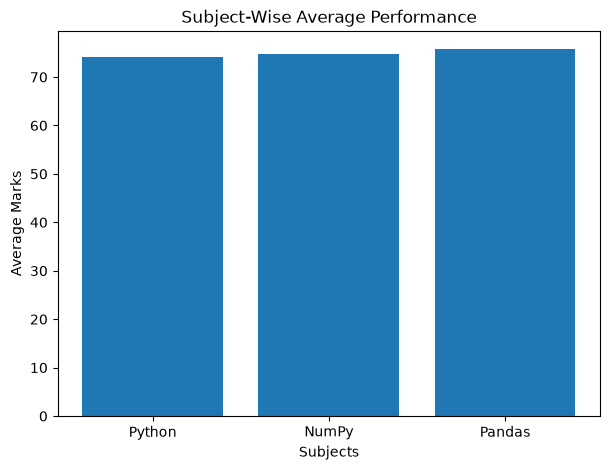

In [22]:
import matplotlib.pyplot as plt

subject_averages = df[subjects].mean()

plt.figure(figsize=(7, 5))
plt.bar(subject_averages.index, subject_averages.values)

plt.title("Subject-Wise Average Performance")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")

plt.show()

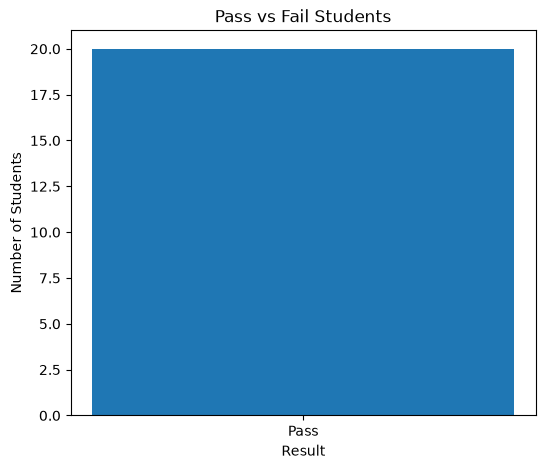

In [23]:
result_counts = df["Result"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(result_counts.index, result_counts.values)

plt.title("Pass vs Fail Students")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

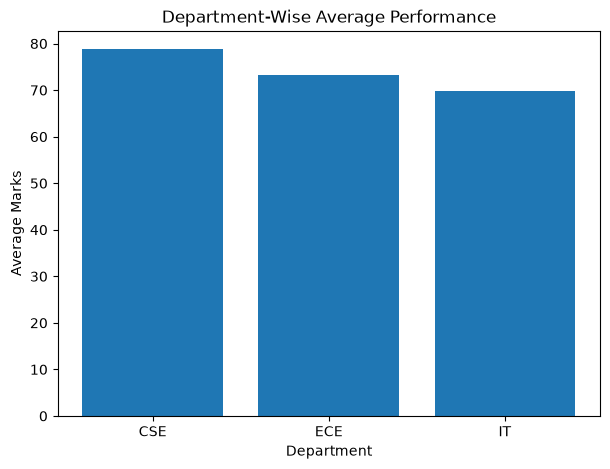

In [24]:
department_average = df.groupby("Department")["Average"].mean()

plt.figure(figsize=(7, 5))

plt.bar(department_average.index, department_average.values)

plt.title("Department-Wise Average Performance")
plt.xlabel("Department")
plt.ylabel("Average Marks")

plt.show()

In [25]:
print("========== STUDENT PERFORMANCE ANALYTICS SYSTEM ==========\n")

print("Total Number of Students:", len(df))
print("Number of Passed Students:", pass_count)
print("Number of Failed Students:", fail_count)

print("\nOverall Class Average:", round(class_average, 2))
print("Highest Average:", highest_average)
print("Lowest Average:", lowest_average)

print("\nTop Performing Student:")
print("Name:", top_student["Name"])
print("Department:", top_student["Department"])
print("Average:", top_student["Average"])
print("Grade:", top_student["Grade"])

print("\nBest Performing Subject:", best_subject)
print("Subject Average:", round(best_average, 2))

print("\nBest Performing Department:", best_department)
print("Department Average:", round(best_department_average, 2))

print("\n==========================================================")

========== STUDENT PERFORMANCE ANALYTICS SYSTEM ==========

Total Number of Students: 20
Number of Passed Students: 20
Number of Failed Students: 0

Overall Class Average: 74.88
Highest Average: 95.33
Lowest Average: 50.0

Top Performing Student:
Name: Varun
Department: CSE
Average: 95.33
Grade: A+

Best Performing Subject: Pandas
Subject Average: 75.7

Best Performing Department: CSE
Department Average: 78.78



In [26]:
df.to_csv("student_performance_final.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [27]:
print(df.to_string(index=False))

 Student_ID    Name Department  Python  NumPy  Pandas  Attendance  Total  Average Grade Result
        101  Ananya        CSE      85     78      90          92    253    84.33     A   Pass
        102 Bhavana        CSE      72     80      75          88    227    75.67     B   Pass
        103  Charan        ECE      65     70      68          82    203    67.67     C   Pass
        104   Divya        CSE      92     89      95          96    276    92.00    A+   Pass
        105   Eswar         IT      55     62      58          75    175    58.33     D   Pass
        106 Fathima        ECE      78     74      80          90    232    77.33     B   Pass
        107 Gowtham        CSE      88     85      82          94    255    85.00     A   Pass
        108  Harini        CSE      60     65      70          80    195    65.00     C   Pass
        109  Ishaan        ECE      45     55      50          68    150    50.00     D   Pass
        110 Jahnavi         IT      95     91     

In [28]:
print("==============================================")
print("       STUDENT PERFORMANCE ANALYTICS SYSTEM")
print("==============================================")

print("\nPROJECT SUMMARY")
print("----------------")

print("Total Students       :", len(df))
print("Passed Students      :", pass_count)
print("Failed Students      :", fail_count)
print("Class Average        :", round(class_average, 2))

print("\nTOP PERFORMER")
print("--------------")
print("Name                 :", top_student["Name"])
print("Department           :", top_student["Department"])
print("Average              :", top_student["Average"])
print("Grade                :", top_student["Grade"])

print("\nBEST SUBJECT")
print("------------")
print("Subject              :", best_subject)
print("Average              :", round(best_average, 2))

print("\nBEST DEPARTMENT")
print("----------------")
print("Department           :", best_department)
print("Average              :", round(best_department_average, 2))

print("\n==============================================")
print("             PROJECT COMPLETED")
print("==============================================")

       STUDENT PERFORMANCE ANALYTICS SYSTEM

PROJECT SUMMARY
----------------
Total Students       : 20
Passed Students      : 20
Failed Students      : 0
Class Average        : 74.88

TOP PERFORMER
--------------
Name                 : Varun
Department           : CSE
Average              : 95.33
Grade                : A+

BEST SUBJECT
------------
Subject              : Pandas
Average              : 75.7

BEST DEPARTMENT
----------------
Department           : CSE
Average              : 78.78

             PROJECT COMPLETED
